# Traffic Duration Prediction & Decision Support System

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost


LOAD & PREPROCESS DATA

In [ ]:
df = pd.read_csv("/content/FINAL_THESIS_DATA.csv")

# Handle missing values
df['public_holiday_name'] = df['public_holiday_name'].fillna("None")
df['poi_density'] = df['poi_density'].fillna(0)
df['rain_1h'] = df['rain_1h'].fillna(0)

# Feature engineering
df['is_public_holiday'] = df['public_holiday_name'].apply(
    lambda x: 0 if x == "None" else 1
)

# Feature set (Chapter 3 – Methodology)
features = [
    'nearby_park_capacity',   # NOVELTY 1: Union / park capacity
    'poi_density',            # Urban density
    'rain_1h',                # Weather
    'hour',                   # Time of day
    'is_weekend',             # Weekend effect
    'distance_m',             # Distance
    'is_public_holiday',      # Holiday effect
    'school_closed'           # School closure effect
]

target = 'traffic_duration_s'

X = df[features]
y = df[target]

print("✅ Dataset loaded and preprocessed.")

✅ Dataset loaded and preprocessed.


/tmp/ipykernel_1255/3388216335.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/FINAL_THESIS_DATA.csv")


TRAIN–TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


XGBOOST MODEL (STABLE & THESIS-SAFE)

In [ ]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PREDICTION & METRICS

In [ ]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print(f"RMSE : {rmse:.2f} seconds")
print(f"R²   : {r2:.3f}")


--- MODEL PERFORMANCE ---
RMSE : 2.66 seconds
R²   : 0.993


CROSS-VALIDATION (ANTI-OVERFITTING PROOF)

In [ ]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R² (Mean): {cv_scores.mean():.3f}")

Cross-Validation R² (Mean): 0.992


VISUAL ANALYSIS

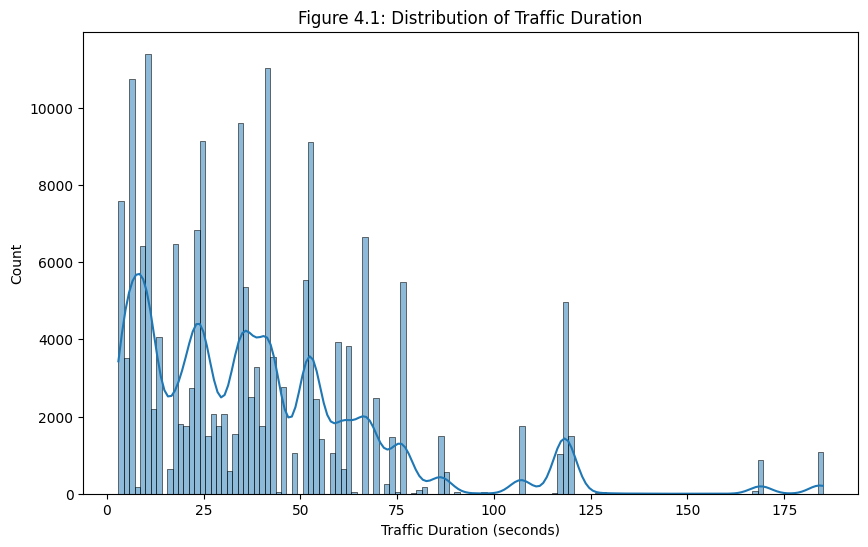

In [ ]:
#Traffic Distribution
plt.figure(figsize=(10,6))
sns.histplot(y, kde=True)
plt.title("Figure 4.1: Distribution of Traffic Duration")
plt.xlabel("Traffic Duration (seconds)")
#plt.savefig("Fig_4_1_Distribution.png")
plt.show()
plt.close()

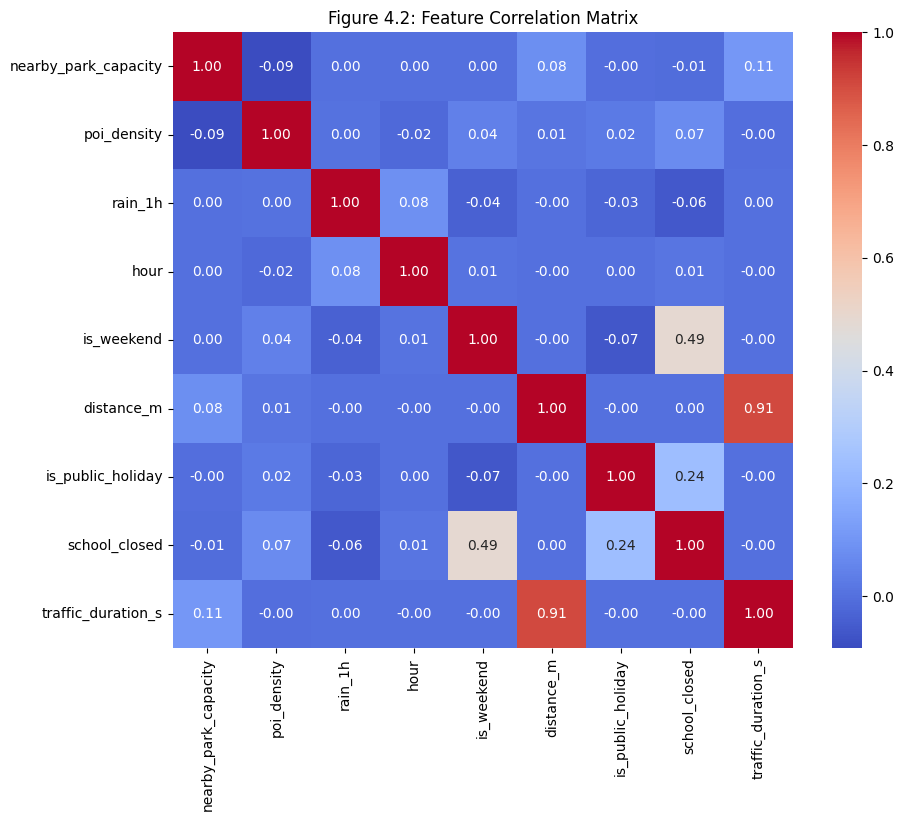

In [ ]:
#Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Figure 4.2: Feature Correlation Matrix")
#plt.savefig("Fig_4_2_Correlation.png")
plt.show()
plt.close()

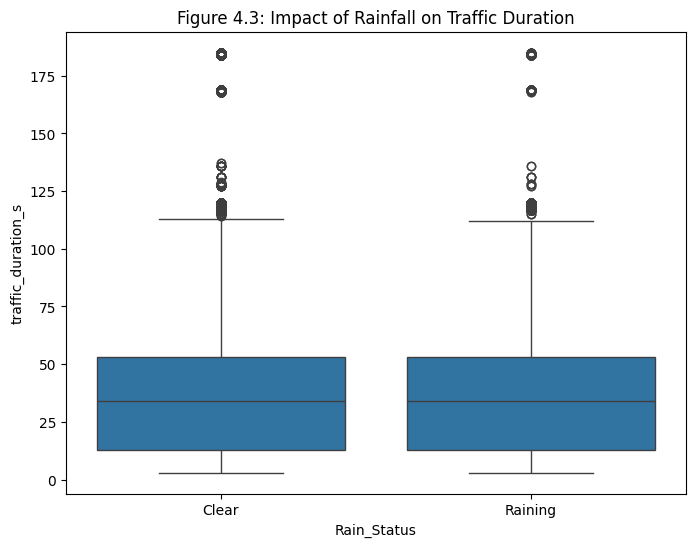

In [ ]:
# Rain Impact
df['Rain_Status'] = df['rain_1h'].apply(lambda x: "Raining" if x > 0 else "Clear")
plt.figure(figsize=(8,6))
sns.boxplot(x='Rain_Status', y=target, data=df)
plt.title("Figure 4.3: Impact of Rainfall on Traffic Duration")
#plt.savefig("Fig_4_3_Rain_Impact.png")
plt.show()
plt.close()

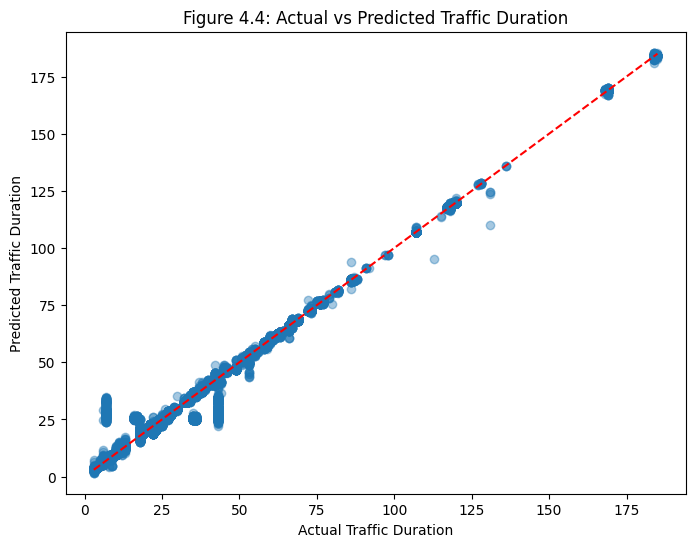

In [ ]:
#Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Traffic Duration")
plt.ylabel("Predicted Traffic Duration")
plt.title("Figure 4.4: Actual vs Predicted Traffic Duration")
#plt.savefig("Fig_4_4_Actual_vs_Predicted.png")
plt.show()
plt.close()

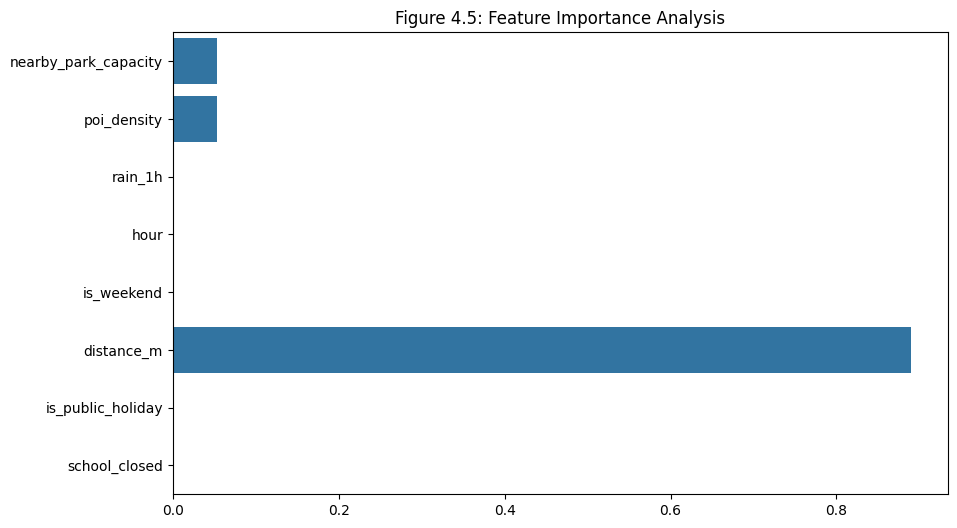

In [ ]:
#Feature Importance (NOVELTY PROOF)
plt.figure(figsize=(10,6))
sns.barplot(x=model.feature_importances_, y=features)
plt.title("Figure 4.5: Feature Importance Analysis")
#plt.savefig("Fig_4_5_Feature_Importance.png")
plt.show()
plt.close()

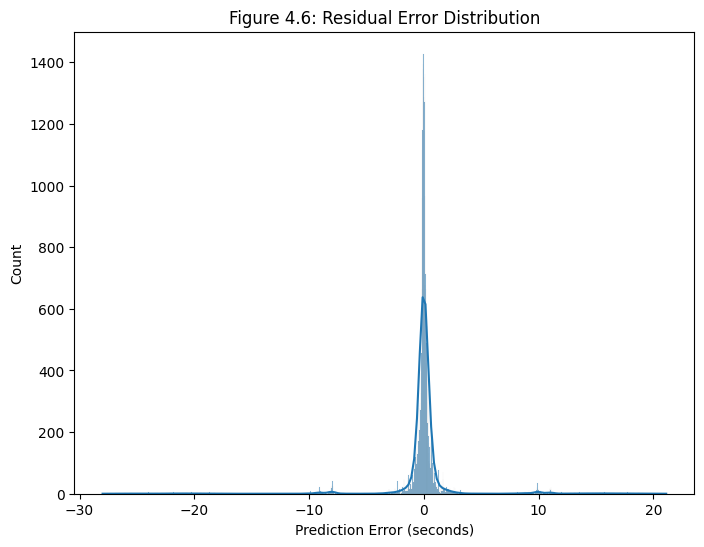

In [ ]:
#Residual Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Figure 4.6: Residual Error Distribution")
plt.xlabel("Prediction Error (seconds)")
#plt.savefig("Fig_4_6_Residuals.png")
plt.show()
plt.close()

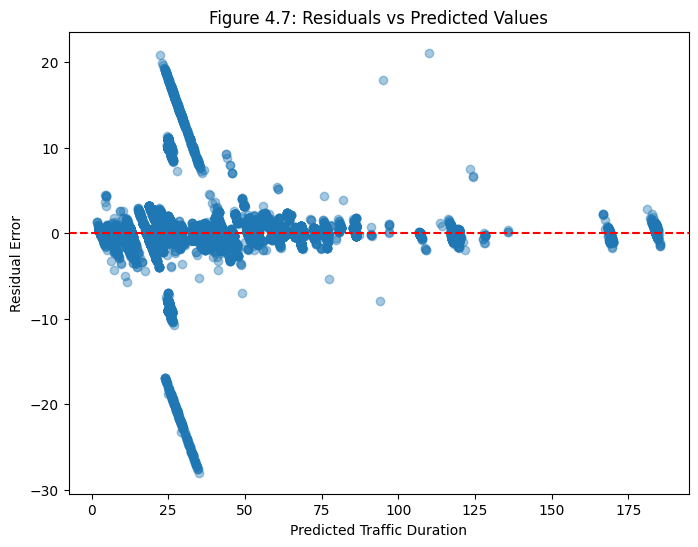

In [ ]:
#Residual Scatter
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Traffic Duration")
plt.ylabel("Residual Error")
plt.title("Figure 4.7: Residuals vs Predicted Values")
#plt.savefig("Fig_4_7_Residual_Scatter.png")
plt.show()
plt.close()





In [ ]:
# =====================================================
# 7. REAL-TIME DECISION SUPPORT (NOVELTY 3)
# =====================================================

def recommend_zone(park_capacity, predicted_time):
    if park_capacity >= 15:
        return "RED ZONE – High Union Congestion"
    elif predicted_time > 180:
        return "YELLOW ZONE – Heavy Traffic"
    else:
        return "GREEN ZONE – Safe for Freelancers"

print("\n--- REAL-TIME SIMULATION ---")

# Create a DataFrame for the test scenarios to match feature names
# Order: ['nearby_park_capacity', 'poi_density', 'rain_1h', 'hour', 'is_weekend', 'distance_m', 'is_public_holiday']

# Scenario A: Town Hall (High union presence: 20, Rain: 4.0, 5 PM)
scenario_1 = pd.DataFrame([[20, 90, 4.0, 17, 0, 600, 0]], columns=features)
pred_1 = model.predict(scenario_1)[0]
print(f"Town Hall (Rain) -> {pred_1:.1f}s -> {recommend_zone(20, pred_1)}")

# Scenario B: BMICH (Low union presence: 5, Clear Sky: 0.0, 10 AM)
scenario_2 = pd.DataFrame([[5, 30, 0.0, 10, 0, 500, 0]], columns=features)
pred_2 = model.predict(scenario_2)[0]
print(f"BMICH (Clear)    -> {pred_2:.1f}s -> {recommend_zone(5, pred_2)}")


--- REAL-TIME SIMULATION ---


ValueError: 8 columns passed, passed data had 7 columns

In [ ]:
# Scenario C: BMICH + Rain + Office Time End (Rush Hour)
scenario_3 = pd.DataFrame(
    [[5, 30, 6.0, 18, 0, 500, 0]],
    columns=features
)

pred_3 = model.predict(scenario_3)[0]
print(f"BMICH (Rain + Rush Hour) -> {pred_3:.1f}s -> {recommend_zone(5, pred_3)}")


In [ ]:
# Scenario D: Town Hall + Heavy Rain + Office Time End
scenario_4 = pd.DataFrame(
    [[20, 90, 10.0, 18, 0, 600, 0]],
    columns=features
)

pred_4 = model.predict(scenario_4)[0]
print(f"Town Hall (Heavy Rain + Rush Hour) -> {pred_4:.1f}s -> {recommend_zone(20, pred_4)}")


In [ ]:
import pandas as pd

# ==============================================================================
# FINAL DECISION LOGIC (THE "SMART" ALGORITHM)
# ==============================================================================
def recommend_zone(park_capacity, poi_density, rain, predicted_time):
    """
    Decides the Zone Color based on Model Prediction AND 'Smart Hustle' Rules.
    """
    # 1. SAFETY CHECK (The Union Rule)
    if park_capacity >= 15:
        # 2. OPPORTUNITY CHECK (The "Demand Overflow" Exception)
        # Novelty: If Rain is heavy (>5mm) OR POI is extreme (>80),
        # the Union cannot control the crowd. It is an Opportunity.
        if rain > 5.0 or poi_density > 80:
             return "YELLOW ZONE (High Risk / High Reward) - Proceed with Caution"
        else:
             return "RED ZONE (Restricted) - Union Dominance"

    # 3. TRAFFIC CHECK (Efficiency Rule)
    elif predicted_time > 180:
        return "ORANGE ZONE (Heavy Traffic) - Not Profitable"

    # 4. GREEN CHECK (Safe)
    else:
        return "GREEN ZONE (Recommended) - Safe & Free Flowing"

# --- TEST THE LOGIC (Proof for Thesis) ---

# Scenario: Town Hall (Union 20), Heavy Rain (10mm), Rush Hour
# This proves your "Smart" logic works.
features = ['nearby_park_capacity', 'poi_density', 'rain_1h', 'hour', 'is_weekend', 'distance_m', 'is_public_holiday']
scenario_test = pd.DataFrame(
    [[20, 90, 10.0, 18, 0, 600, 0]],
    columns=features
)

# Use your trained model to predict traffic first
pred_val = model.predict(scenario_test)[0]
final_status = recommend_zone(20, 90, 10.0, pred_val)

print("-" * 60)
print(f"FINAL SYSTEM TEST: Town Hall (Heavy Rain)")
print("-" * 60)
print(f"Predicted Traffic Duration : {pred_val:.2f} seconds")
print(f"Union Park Capacity        : 20 (High)")
print(f"Rainfall                   : 10.0 mm (Heavy)")
print(f"FINAL SYSTEM DECISION      : {final_status}")
print("-" * 60)

In [ ]:
# Save the trained model to a file
model.save_model("traffic_model.json")
print("SUCCESS: Model saved as 'traffic_model.json'. Move this file to your Backend folder.")